In [6]:
!nvidia-smi

Thu Nov 20 02:51:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!unzip /content/dataset.zip

Archive:  /content/dataset.zip
  inflating: imbalanced_data.csv     
  inflating: raw_data.csv            


In [8]:
import pandas as pd

In [9]:
imbalanced_data = pd.read_csv('/content/imbalanced_data.csv')

In [10]:
imbalanced_data.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## EDA

In [11]:
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

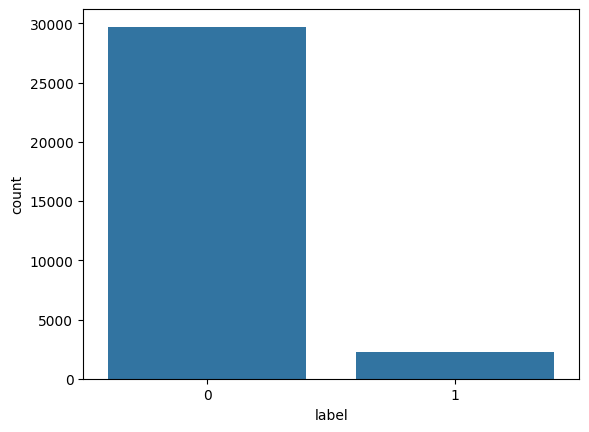

In [12]:
sns.countplot(x='label', data=imbalanced_data)

- 0 --> No hate
- 1 --> Hate

In [13]:
imbalanced_data.shape

(31962, 3)

In [14]:
imbalanced_data.isnull().sum()

,0
id,0
label,0
tweet,0


In [15]:
imbalanced_data.drop('id', axis=1, inplace=True)

In [16]:
imbalanced_data.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [17]:
raw_data = pd.read_csv('/content/raw_data.csv')

In [18]:
raw_data.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [19]:
raw_data.shape

(24783, 7)

In [20]:
raw_data.isnull().sum()

,0
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0


In [21]:
raw_data.drop(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither'], axis=1, inplace=True)

In [22]:
raw_data.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [23]:
raw_data.rename(columns={'class': 'label'}, inplace=True)

In [24]:
raw_data.head()

,label,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [25]:
raw_data['label'].unique()

array([2, 1, 0])

<Axes: xlabel='label', ylabel='count'>

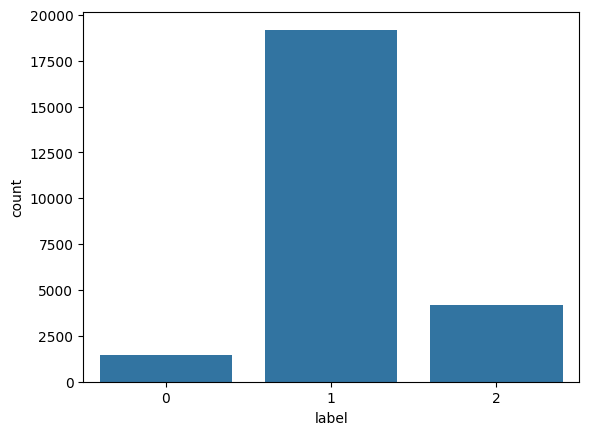

In [26]:
sns.countplot(x='label', data=raw_data)

- class 0 : hate
- class 1 : abusive
- class 2: no hate

In [27]:
# Let's copy the calue of the class 1 into 0 (so we only have hate or no hate)
raw_data[raw_data['label'] == 0]['label'] == 1

,label
85,False
89,False
110,False
184,False
202,False
...,...
24576,False
24685,False
24751,False
24776,False


In [28]:
raw_data.head()

,label,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [29]:
raw_data['label'].unique()

array([2, 1, 0])

In [30]:
# Let's check the values in class 0
raw_data[raw_data['label'] == 0]

,label,tweet
85,0,"""@Blackman38Tide: @WhaleLookyHere @HowdyDowdy1..."
89,0,"""@CB_Baby24: @white_thunduh alsarabsss"" hes a ..."
110,0,"""@DevilGrimz: @VigxRArts you're fucking gay, b..."
184,0,"""@MarkRoundtreeJr: LMFAOOOO I HATE BLACK PEOPL..."
202,0,"""@NoChillPaz: ""At least I'm not a nigger"" http..."
...,...,...
24576,0,this guy is the biggest faggot omfg
24685,0,which one of these names is more offensive kik...
24751,0,you a pussy ass nigga and I know it nigga.
24776,0,you're all niggers


In [31]:
raw_data['label'].replace({0: 1}, inplace=True)

/tmp/ipython-input-1681782001.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data['label'].replace({0: 1}, inplace=True)


In [32]:
raw_data['label'].unique()

array([2, 1])

<Axes: xlabel='label', ylabel='count'>

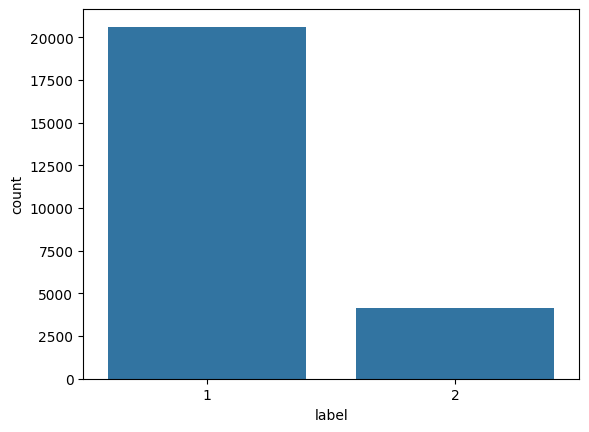

In [33]:
sns.countplot(x='label', data=raw_data)

In [34]:
raw_data['label'].replace({2: 0}, inplace=True)

/tmp/ipython-input-4151732953.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data['label'].replace({2: 0}, inplace=True)


<Axes: xlabel='label', ylabel='count'>

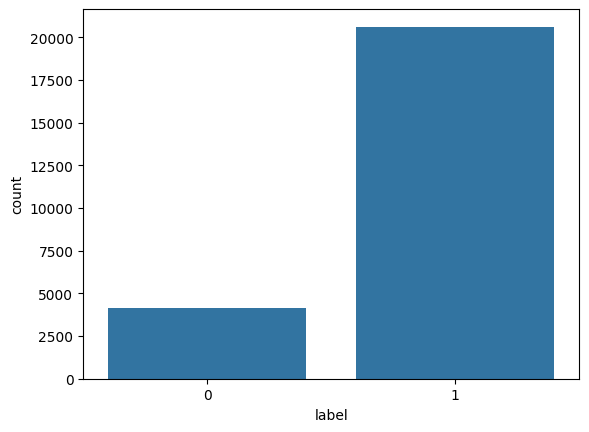

In [35]:
sns.countplot(x='label', data=raw_data)

In [36]:
imbalanced_data.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [37]:
raw_data.head()

,label,tweet
0,0,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [38]:
frame = [imbalanced_data, raw_data]
df = pd.concat(frame)

In [39]:
df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [40]:
df.shape

(56745, 2)

<Axes: xlabel='label', ylabel='count'>

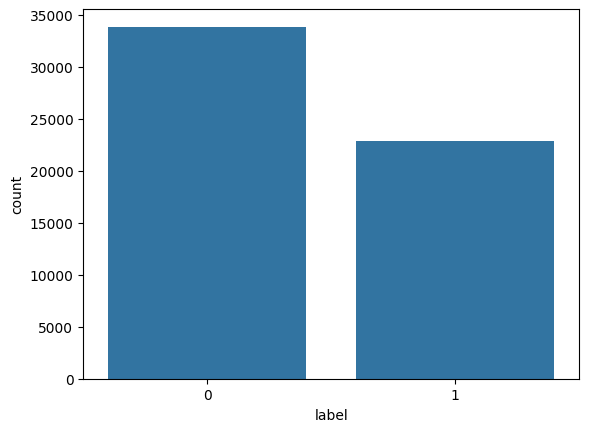

In [41]:
sns.countplot(x='label', data=df)

## Preprocessing

In [42]:
import re
import nltk
from nltk.corpus import stopwords
import string
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [43]:
stemmer = nltk.SnowballStemmer('english')
stopword = set(stopwords.words('english'))

In [44]:
def data_cleaning(words):
  words = str(words).lower()
  words = re.sub(r'\[.*?\]', '', words)
  words = re.sub(r'https?://\S+|www\.\S+', '', words)
  words = re.sub(r'<.*?>+', '', words)
  words = re.sub(r'[%s]' % re.escape(string.punctuation), '', words)
  words = re.sub(r'\n', '', words)
  words = re.sub(r'\w*\d\w*', '', words)
  words = [word for word in words.split(' ') if word not in stopword]
  words = ' '.join(words)
  words = [stemmer.stem(word) for word in words.split(' ')]
  words = ' '.join(words)
  return words


In [45]:
df['tweet'][1]

,tweet
1,@user @user thanks for #lyft credit i can't us...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...


In [46]:
df['tweet']=df['tweet'].apply(data_cleaning)

In [47]:
df['tweet'][1]

,tweet
1,user user thank lyft credit cant use caus dont...
1,rt boy dat coldtyga dwn bad cuffin dat hoe ...


In [48]:
x = df['tweet']
y = df['label']

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
#Let's split the data into train and test

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

print(len(x_train), len(y_train))
print(len(x_test), len(y_test))

42558 42558
14187 14187


## Feature Engineering

In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [52]:
max_words = 50000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)

sequences = tokenizer.texts_to_sequences(x_train)
sequences_matrix = pad_sequences(sequences, maxlen=max_len)

In [53]:
sequences_matrix

array([[    0,     0,     0, ..., 15028,  6270,  3012],
       [    0,     0,     0, ...,   407,    95,   235],
       [    0,     0,     0, ...,   680,   634, 15029],
       ...,
       [    0,     0,     0, ...,   111,    77, 46968],
       [    0,     0,     0, ...,   910, 11895,   712],
       [    0,     0,     0, ...,   350,   314,     2]], dtype=int32)

In [54]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Activation, Dropout, Input
from keras.optimizers import RMSprop

In [57]:
# Creating model architecture
model = Sequential()
model.add(Embedding(max_words, 100, input_shape=(max_len,)))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,080,501 (19.38 MB)

 Trainable params: 5,080,501 (19.38 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(loss='binary_crossentropy', optimizer=RMSprop(), metrics=['accuracy'])

In [60]:
# Starting model training
history = model.fit(sequences_matrix, y_train, batch_size=128, epochs=1, validation_split=0.2)

266/266 ━━━━━━━━━━━━━━━━━━━━ 271s 991ms/step - accuracy: 0.7946 - loss: 0.4308 - val_accuracy: 0.9410 - val_loss: 0.1721


In [61]:
test_sequences = tokenizer.texts_to_sequences(x_test)
test_sequences_matrix = pad_sequences(test_sequences, maxlen=max_len)

In [62]:
test_sequences_matrix

array([[    0,     0,     0, ...,  1401,     2,  2903],
       [    0,     0,     0, ...,   776,  2521, 14986],
       [    0,     0,     0, ...,   181,   214,   976],
       ...,
       [    0,     0,     0, ...,   217,    19,   221],
       [    0,     0,     0, ...,   352,     1,     1],
       [    0,     0,     0, ...,   265,   785,   244]], dtype=int32)

In [63]:
# Model evaluation
accr = model.evaluate(test_sequences_matrix, y_test)

444/444 ━━━━━━━━━━━━━━━━━━━━ 79s 176ms/step - accuracy: 0.9341 - loss: 0.1841


In [64]:
lstm_prediction = model.predict(test_sequences_matrix)

444/444 ━━━━━━━━━━━━━━━━━━━━ 77s 169ms/step


In [65]:
res = []
for prediction in lstm_prediction:
  if prediction[0] < 0.5:
    res.append(0)
  else:
    res.append(1)

In [66]:
from sklearn.metrics import confusion_matrix

In [67]:
print(confusion_matrix(y_test, res))

[[8200  253]
 [ 684 5050]]


In [68]:
# We save the Tokenizer
import pickle

with open('tokenizer.pickle', 'wb') as handle:
  pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [69]:
# We save the model
model.save("model.h5")

In [70]:
import keras

In [71]:
load_model = keras.models.load_model('model.h5')
with open('tokenizer.pickle', 'rb') as handle:
  load_tokenizer = pickle.load(handle)

In [87]:
# Now we can test our code on some custom data

test = 'The frog ate the fly'
print(test)

test = [data_cleaning(test)]
print(test)

test_sequence = load_tokenizer.texts_to_sequences(test)
test_sequence_matrix = pad_sequences(test_sequence, maxlen=max_len)

prediction = load_model.predict(test_sequence_matrix)

print("pred", prediction)

if prediction < 0.5:
  print("No hate")
else:
  print("Hate and abusive")


The frog ate the fly
['frog ate fli']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
pred [[0.21603878]]
No hate
